In [1]:
import torch


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda:0


In [7]:
import os

# Path
OBJ_FILENAME = "models/Guitar.obj"
assert os.path.exists(OBJ_FILENAME), f"File is not found: {OBJ_FILENAME}"

In [8]:
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import TexturesAtlas
import open3d as o3d
import numpy as np


# load + decimate + synthetic texture (FACE-BASED)
def load_and_decimate(obj_filename, device, target_faces=3000):
    verts, faces, _ = load_obj(obj_filename, device='cpu')
    faces_idx = faces.verts_idx

    # Rotation (so that the guitar stands properly)
    verts = verts[:, [0, 2, 1]]

    # --- DECIMATION ---
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices  = o3d.utility.Vector3dVector(verts.numpy())
    o3d_mesh.triangles = o3d.utility.Vector3iVector(faces_idx.numpy())

    o3d_mesh = o3d_mesh.simplify_quadric_decimation(target_faces)

    verts     = torch.tensor(np.asarray(o3d_mesh.vertices), dtype=torch.float32)
    faces_idx = torch.tensor(np.asarray(o3d_mesh.triangles), dtype=torch.int64)

    print(f"Decimated → {faces_idx.shape[0]} faces")

    verts     = verts.to(device)
    faces_idx = faces_idx.to(device)

    # RANDOM TEXTURE ON A TRIANGLE
    F = faces_idx.shape[0]
    atlas = torch.rand((1, F, 1, 1, 3), device=device)

    textures = TexturesAtlas(atlas=atlas)

    mesh = Meshes(
        verts=[verts],
        faces=[faces_idx],
        textures=textures
    )

    return mesh

In [9]:
def normalize_mesh(mesh):
    verts = mesh.verts_packed()
    center = verts.mean(0)
    scale = torch.max(torch.norm(verts - center, dim=1)).item()

    mesh = mesh.offset_verts(-center)
    mesh = mesh.scale_verts(1.0 / scale)

    return mesh, center, scale


mesh, mesh_center, mesh_scale = normalize_mesh(
    load_and_decimate(OBJ_FILENAME, device, target_faces=3000)
)

print(f"Vertices: {mesh.verts_packed().shape[0]}, Faces: {mesh.faces_packed().shape[0]}")

/home/mad03633/Assign_3/graphics/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:548: UserWarning: Mtl file does not exist: models/19361_Guitar_V1.mtl
  warnings.warn(f"Mtl file does not exist: {f}")


Decimated → 3000 faces
Vertices: 1530, Faces: 3000


X range: -0.332 to 0.342
Y range: -0.432 to 0.949
Z range: -0.057 to 0.166


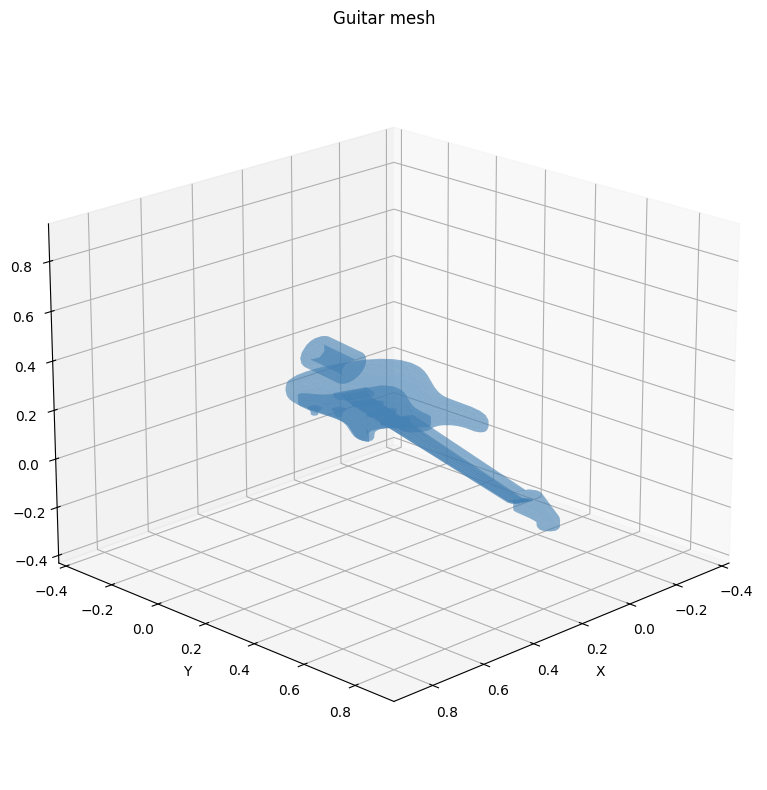

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
 
verts_np = mesh.verts_packed().detach().cpu().numpy()
faces_np = mesh.faces_packed().detach().cpu().numpy()
 
print("X range:", verts_np[:,0].min().round(3), "to", verts_np[:,0].max().round(3))
print("Y range:", verts_np[:,1].min().round(3), "to", verts_np[:,1].max().round(3))
print("Z range:", verts_np[:,2].min().round(3), "to", verts_np[:,2].max().round(3))
 
idx  = np.random.choice(len(faces_np), min(3000, len(faces_np)), replace=False)
fig  = plt.figure(figsize=(8, 8))
ax   = fig.add_subplot(111, projection='3d')
poly = Poly3DCollection(verts_np[faces_np[idx]], alpha=0.4,
                        facecolor='steelblue', edgecolor='none')
ax.add_collection3d(poly)
 
# Equal scale on all axes
all_v = np.concatenate([verts_np[:,0], verts_np[:,1], verts_np[:,2]])
vmin, vmax = all_v.min(), all_v.max()
ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax); ax.set_zlim(vmin, vmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Guitar mesh')
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt


def show_image(img, title=None, cmap=None):
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

In [12]:
from pytorch3d.renderer import (
    BlendParams, 
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftSilhouetteShader,
    SoftPhongShader,
    PointLights
)


# Renderer
IMG_SIZE = 256

def get_silhouette_renderer(image_size=256):
    blend_params = BlendParams(sigma=1e-4, gamma=1e-4)

    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=np.log(1. / 1e-4 - 1.) * blend_params.sigma,
        faces_per_pixel=50,
    )

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(raster_settings=raster_settings),
        shader=SoftSilhouetteShader(blend_params=blend_params)
    )
    return renderer


def get_rgb_renderer(device, image_size=256):
    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=0.0,
        faces_per_pixel=1,
    )

    lights = PointLights(device=device, location=[[2.0, 2.0, -2.0]])

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(raster_settings=raster_settings),
        shader=SoftPhongShader(device=device, lights=lights)
    )
    return renderer


silhouette_renderer = get_silhouette_renderer(IMG_SIZE)
rgb_renderer = get_rgb_renderer(device, IMG_SIZE)

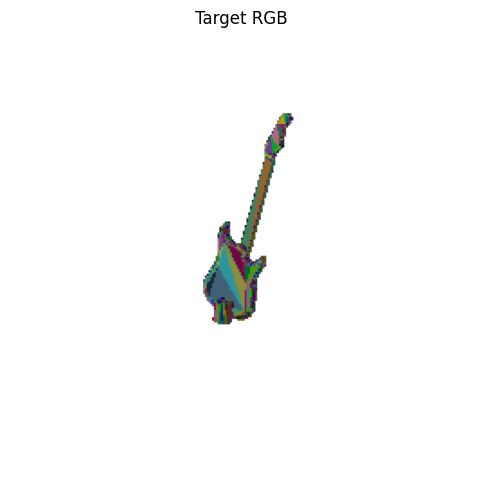

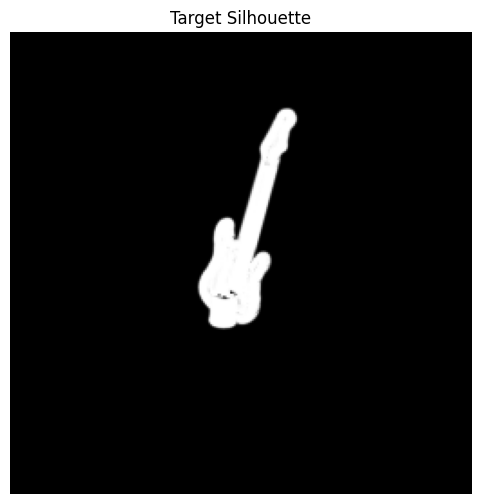

In [13]:
from pytorch3d.renderer import FoVPerspectiveCameras, look_at_view_transform

# Generate target images from the true pose

# Initial pose of camera
target_distance = 2.7
target_elevation = 20.0
target_azimuth = 35.0

R_target, T_target = look_at_view_transform(
    dist=target_distance,
    elev=target_elevation,
    azim=target_azimuth,
    device=device
)

target_cameras = FoVPerspectiveCameras(device=device, R=R_target, T=T_target)

with torch.no_grad():
    target_rgb = rgb_renderer(mesh, cameras=target_cameras)[0, ..., :3]
    target_silhouette = silhouette_renderer(mesh, cameras=target_cameras)[0, ..., 3]

show_image(target_rgb, "Target RGB")
show_image(target_silhouette, "Target Silhouette", cmap="gray")

In [ ]:
import torch.nn as nn


# Optimization model of camera
class CameraPoseModel(nn.Module):
    def __init__(self, mesh, device,
                 init_distance=3.5, init_elevation=5.0, init_azimuth=-60.0):
        super().__init__()

        self.mesh = mesh
        self.device = device

        self.distance = nn.Parameter(torch.tensor([init_distance], device=device))
        self.elevation = nn.Parameter(torch.tensor([init_elevation], device=device))
        self.azimuth = nn.Parameter(torch.tensor([init_azimuth], device=device))

        self.silhouette_renderer = get_silhouette_renderer(IMG_SIZE)
        self.rgb_renderer = get_rgb_renderer(device, IMG_SIZE)

    def forward(self):
        R, T = look_at_view_transform(
            dist=self.distance,
            elev=self.elevation,
            azim=self.azimuth,
            device=self.device
        )

        cameras = FoVPerspectiveCameras(device=self.device, R=R, T=T)

        pred_rgb = self.rgb_renderer(self.mesh, cameras=cameras)[0, ..., :3]
        pred_silh = self.silhouette_renderer(self.mesh, cameras=cameras)[0, ..., 3]

        return pred_rgb, pred_silh

In [16]:
import torch.nn.functional as F

# Loss
def weighted_loss(pred_rgb, pred_silh, target_rgb, target_silh, w_silh, w_tex):
    silh_loss = F.mse_loss(pred_silh, target_silh)
    tex_loss = F.mse_loss(pred_rgb, target_rgb)
    total = w_silh * silh_loss + w_tex * tex_loss
    return total, silh_loss, tex_loss

In [19]:
# Training loops
def run_experiment(w_silh, w_tex, num_iters=200):
    model = CameraPoseModel(mesh, device).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

    history = []

    for i in range(num_iters):
        optimizer.zero_grad()

        pred_rgb, pred_silh = model()

        loss, silh_loss, tex_loss = weighted_loss(
            pred_rgb, pred_silh,
            target_rgb, target_silhouette,
            w_silh, w_tex
        )

        loss.backward()
        optimizer.step()

        history.append(loss.item())

        if (i + 1) % 50 == 0:
            print(f"{i+1}: total={loss.item():.4f}")

    with torch.no_grad():
        final_rgb, final_silh = model()

    return {
        "model": model,
        "history": history,
        "final_rgb": final_rgb,
        "final_silh": final_silh
    }

In [20]:
# Experiments
experiments = [
    (1, 0),
    (0, 1),
    (1, 0.1),
    (1, 0.3)
]

results = {}

for w_silh, w_tex in experiments:
    print("=" * 50)
    print(f"Running: w_silh={w_silh}, w_tex={w_tex}")

    res = run_experiment(w_silh, w_tex)

    key = f"silh={w_silh}, tex={w_tex}"
    results[key] = res

Running: w_silh=1, w_tex=0
50: total=0.0182
100: total=0.0164
150: total=0.0145
200: total=0.0126
Running: w_silh=0, w_tex=1
50: total=0.0344
100: total=0.0122
150: total=0.0122
200: total=0.0122
Running: w_silh=1, w_tex=0.1
50: total=0.0192
100: total=0.0173
150: total=0.0153
200: total=0.0133
Running: w_silh=1, w_tex=0.3
50: total=0.0210
100: total=0.0190
150: total=0.0168
200: total=0.0147


silh=1, tex=0


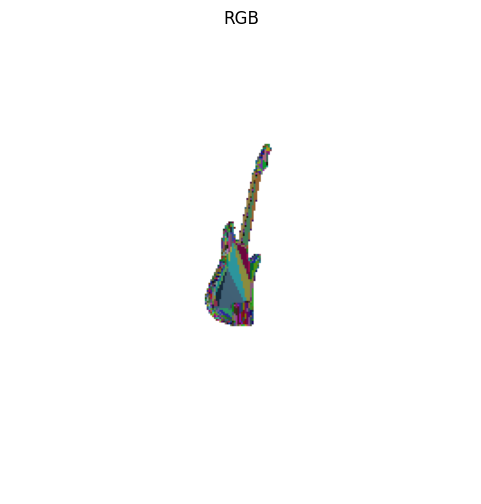

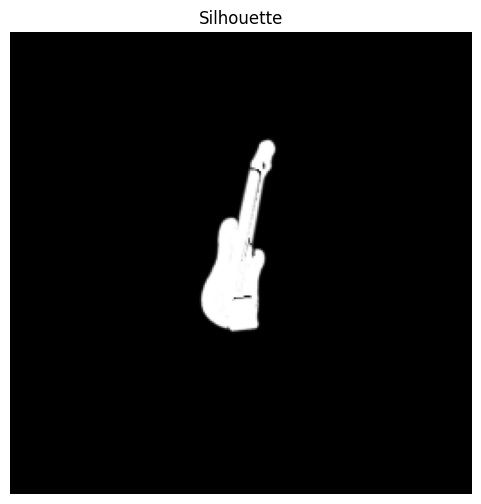

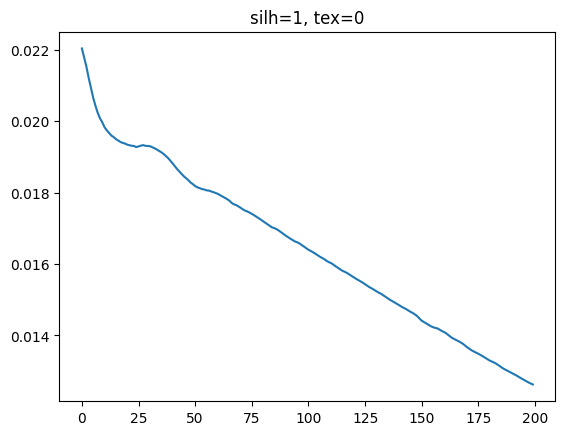

silh=0, tex=1


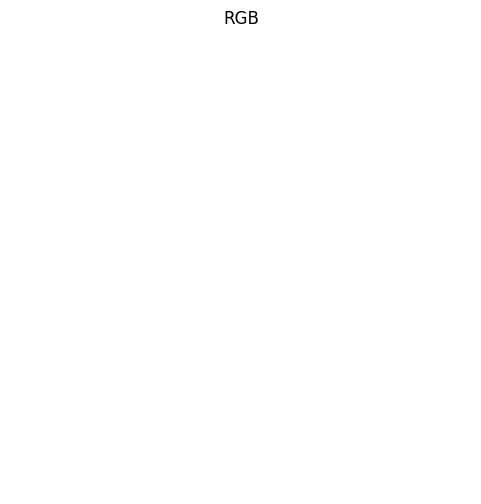

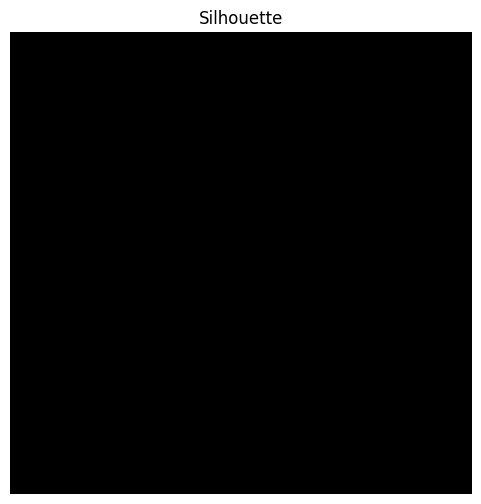

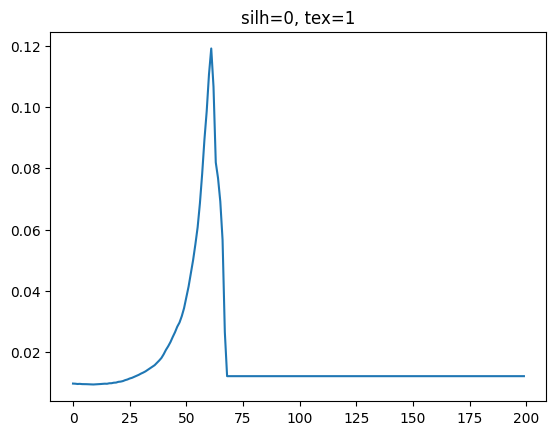

silh=1, tex=0.1


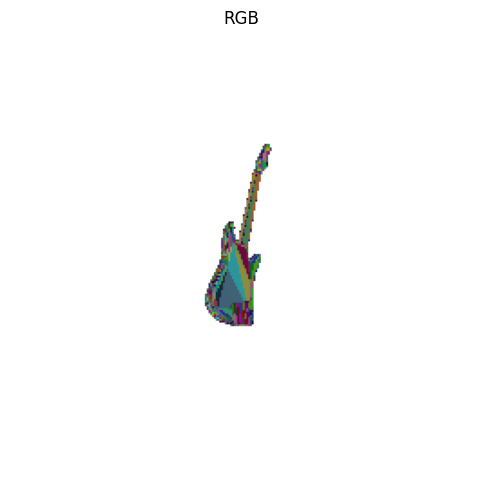

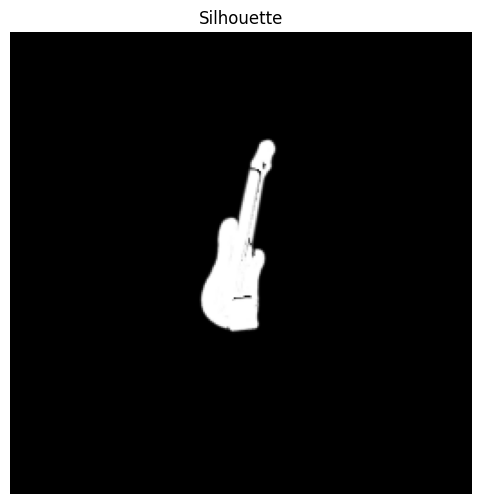

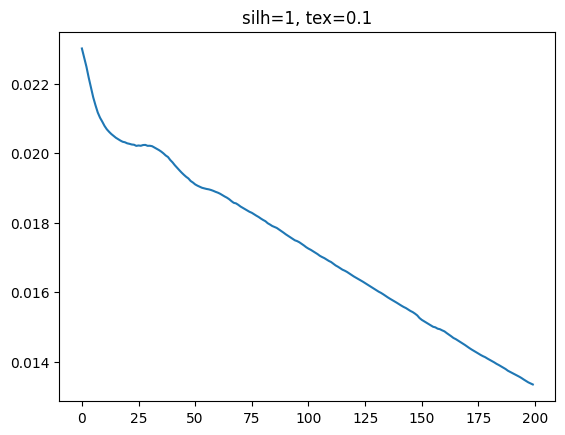

silh=1, tex=0.3


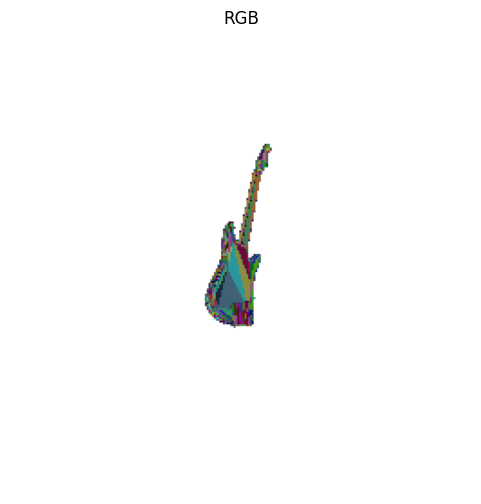

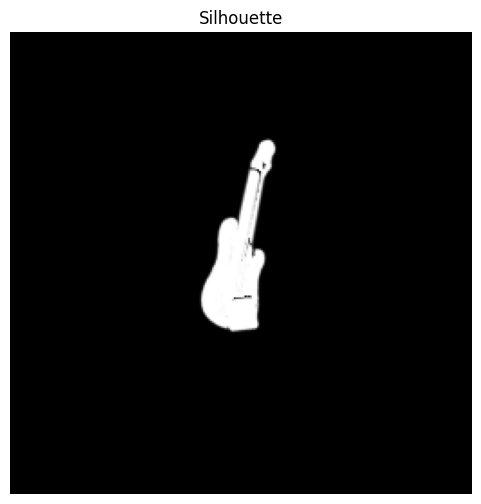

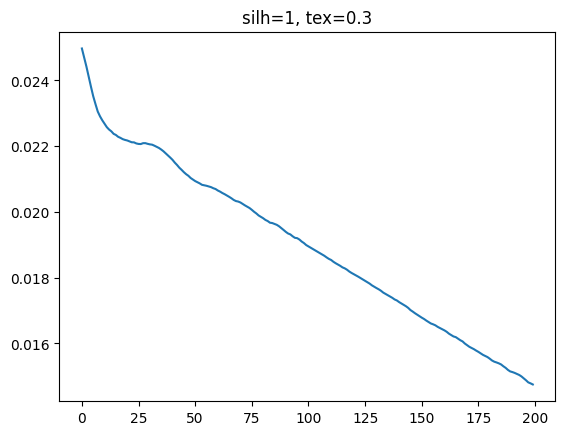

In [21]:
# Visualization
for key, res in results.items():
    print(key)

    show_image(res["final_rgb"], "RGB")
    show_image(res["final_silh"], "Silhouette", cmap="gray")

    plt.plot(res["history"])
    plt.title(key)
    plt.show()